         date  down_hole_presure  down_hole_temperature  \
0  13/07/2008            260.867                103.293   
1  14/07/2008            256.248                104.018   
2  15/07/2008            254.983                103.967   
3  16/07/2008            251.476                104.211   
4  17/07/2008            249.346                104.339   

   production_pipe_pressure  choke_size_pct  well_head_presure  \
0                   160.152          21.053            100.715   
1                   156.650          27.223             99.598   
2                   156.333          27.278             98.650   
3                   155.817          30.651             95.659   
4                   155.761          32.563             93.585   

   well_head_temperature  choke_size_pressure      oil  
0                 52.382               69.539  1735.26  
1                 71.115               68.016   592.36  
2                 67.591               66.949  2532.21  
3                 73

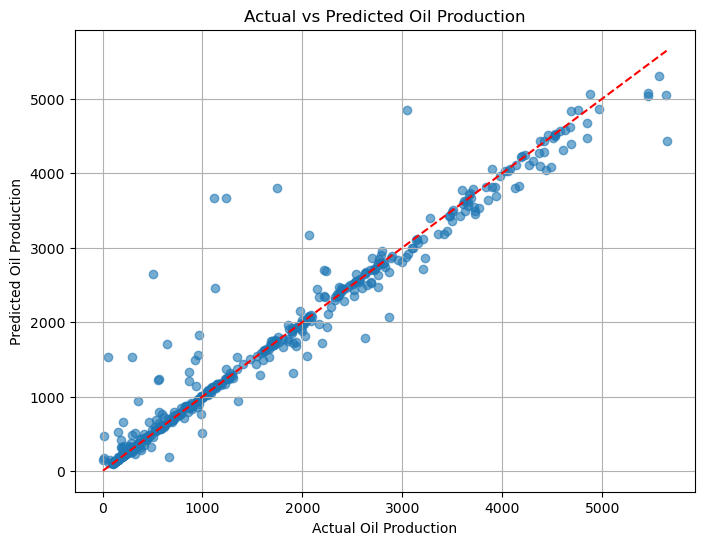

In [17]:
#RANDOM FOREST
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_csv("volve_field_data.csv")

print(df.head())
df.dropna(inplace=True)


df["date"] = pd.to_datetime(df["date"], dayfirst=True)

# Extract useful date features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

# Remove original date column
df.drop("date", axis=1, inplace=True)

X = df.drop("oil", axis=1)
y = df["oil"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("=" * 40)
print("Model Performance")
print("=" * 40)

print(f"MAE       : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE       : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE      : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R² Score  : {r2_score(y_test, y_pred):.4f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Actual Oil Production")
plt.ylabel("Predicted Oil Production")
plt.title("Actual vs Predicted Oil Production")
plt.grid(True)
plt.show()



LINEAR REGRESSION RESULTS
MAE       : 402.1646
MSE       : 378110.1457
RMSE      : 614.9066
R² Score  : 0.7864

Feature Coefficients
                    Feature  Coefficient
0         down_hole_presure    -3.668638
1     down_hole_temperature    10.805380
2  production_pipe_pressure    -0.684619
3            choke_size_pct    -0.298909
4         well_head_presure     3.634349
5     well_head_temperature    14.671034
6       choke_size_pressure     4.230467
7                      year  -412.382476
8                     month   -23.332940
9                       day     1.639575


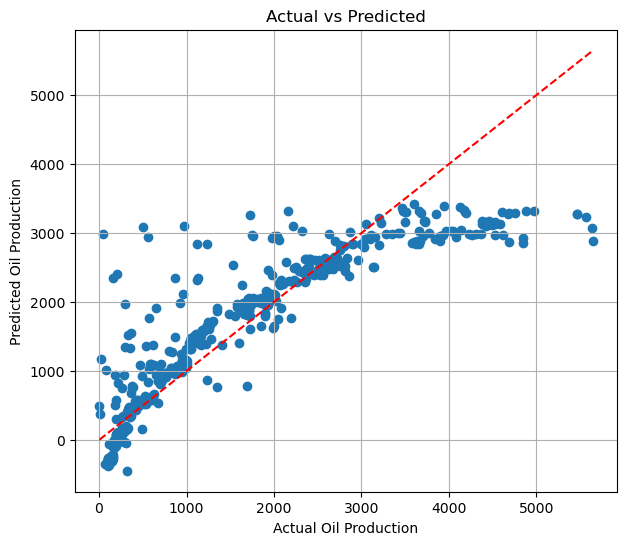

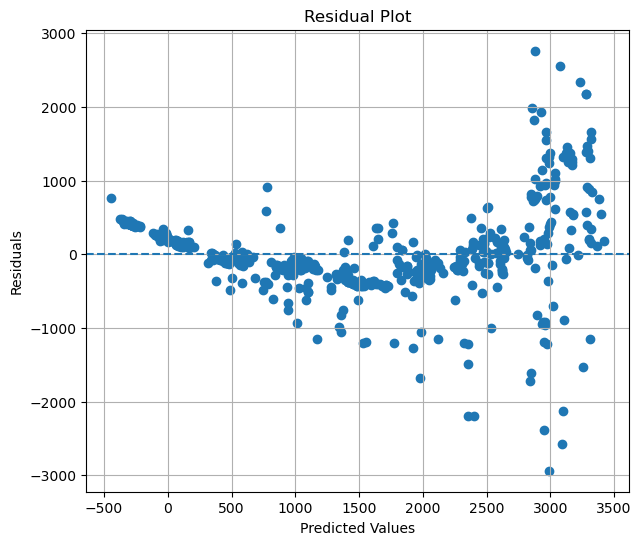

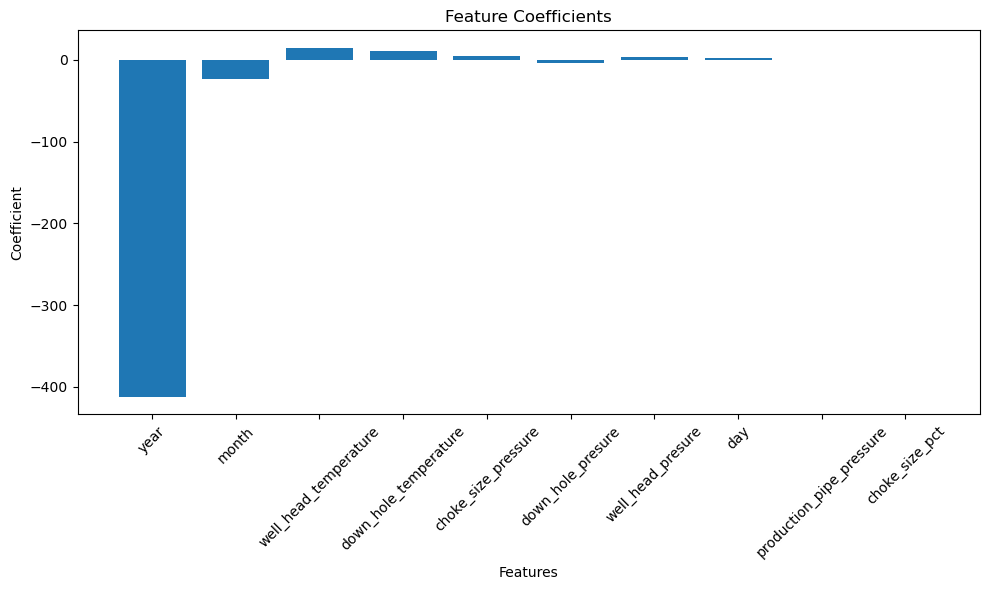

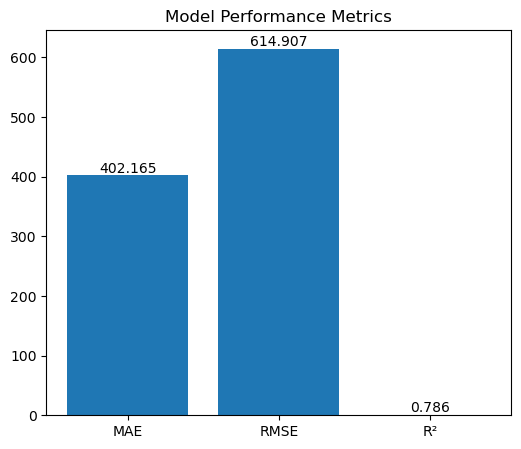

In [15]:
#linear regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ---------------------------------
# Load Dataset
# ---------------------------------

df = pd.read_csv("volve_field_data.csv")

# Remove missing values
df.dropna(inplace=True)

# ---------------------------------
# Convert Date Column
# ---------------------------------

df["date"] = pd.to_datetime(df["date"], dayfirst=True)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

df.drop("date", axis=1, inplace=True)

# ---------------------------------
# Features and Target
# ---------------------------------

X = df.drop("oil", axis=1)
y = df["oil"]

# ---------------------------------
# Train-Test Split
# ---------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ---------------------------------
# Train Model
# ---------------------------------

model = LinearRegression()

model.fit(X_train, y_train)

# ---------------------------------
# Prediction
# ---------------------------------

y_pred = model.predict(X_test)

# ---------------------------------
# Evaluation
# ---------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("LINEAR REGRESSION RESULTS")
print("=" * 50)

print(f"MAE       : {mae:.4f}")
print(f"MSE       : {mse:.4f}")
print(f"RMSE      : {rmse:.4f}")
print(f"R² Score  : {r2:.4f}")

# ---------------------------------
# Feature Coefficients
# ---------------------------------

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nFeature Coefficients")
print(coefficients)

# ---------------------------------
# Plot 1 : Actual vs Predicted
# ---------------------------------

plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Oil Production")
plt.ylabel("Predicted Oil Production")
plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

# ---------------------------------
# Plot 2 : Residual Plot
# ---------------------------------

residuals = y_test - y_pred

plt.figure(figsize=(7,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(True)

plt.show()

# ---------------------------------
# Plot 3 : Feature Importance
# ---------------------------------

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

plt.figure(figsize=(10,6))

plt.bar(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xticks(rotation=45)

plt.title("Feature Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient")

plt.tight_layout()

plt.show()

# ---------------------------------
# Plot 4 : Error Metrics
# ---------------------------------

metrics = ["MAE", "RMSE", "R²"]
values = [mae, rmse, r2]

plt.figure(figsize=(6,5))

plt.bar(metrics, values)

for i, v in enumerate(values):
    plt.text(i, v, f"{v:.3f}", ha="center", va="bottom")

plt.title("Model Performance Metrics")

plt.show()

K-Means Evaluation
Number of Clusters      : 3
Inertia                : 16463.505558592326
Silhouette Score       : 0.38223456702180014
Davies-Bouldin Index   : 0.9796728713390296
Calinski-Harabasz Score: 1027.2277102667117


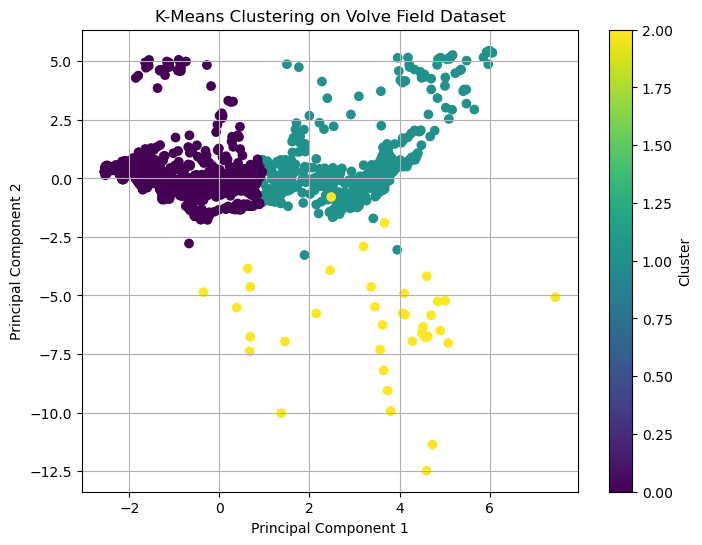

In [6]:
#unsupervised ,k-means clustering

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("volve_field_data.csv")

# Remove missing values
df.dropna(inplace=True)

# -----------------------------
# Convert Date Column
# -----------------------------
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

df.drop("date", axis=1, inplace=True)

# -----------------------------
# Features (Exclude Target)
# -----------------------------
X = df.drop("oil", axis=1)

# -----------------------------
# Standardize Features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Train K-Means
# -----------------------------
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

# -----------------------------
# Evaluation
# -----------------------------
print("=" * 40)
print("K-Means Evaluation")
print("=" * 40)

print("Number of Clusters      :", kmeans.n_clusters)
print("Inertia                :", kmeans.inertia_)
print("Silhouette Score       :", silhouette_score(X_scaled, clusters))
print("Davies-Bouldin Index   :", davies_bouldin_score(X_scaled, clusters))
print("Calinski-Harabasz Score:", calinski_harabasz_score(X_scaled, clusters))

# -----------------------------
# PCA Visualization
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering on Volve Field Dataset")

plt.colorbar(scatter, label="Cluster")

plt.grid(True)

plt.show()

Neural Network Evaluation
MAE       : 153.5369
MSE       : 104875.2034
RMSE      : 323.8444
R² Score  : 0.9407


C:\Users\AkashPrasanth\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


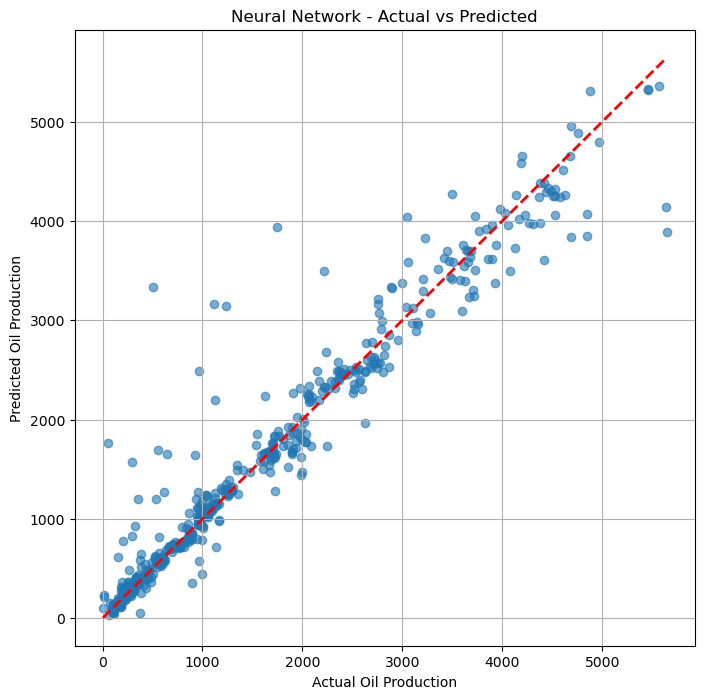

In [7]:
#Neural network
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Load Dataset

df = pd.read_csv("volve_field_data.csv")

df.dropna(inplace=True)


# Convert Date

df["date"] = pd.to_datetime(df["date"], dayfirst=True)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

df.drop("date", axis=1, inplace=True)


# Features and Target

X = df.drop("oil", axis=1)
y = df["oil"]


# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Neural Network Model

model = MLPRegressor(
    hidden_layer_sizes=(64,32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)


# Evaluation

print("=" * 40)
print("Neural Network Evaluation")
print("=" * 40)

print(f"MAE       : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE       : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE      : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R² Score  : {r2_score(y_test, y_pred):.4f}")


# Actual vs Predicted Plot

plt.figure(figsize=(8,8))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Oil Production")
plt.ylabel("Predicted Oil Production")
plt.title("Neural Network - Actual vs Predicted")
plt.grid(True)

plt.show()

TRAINED Q TABLE
[[0.65609985 0.729     ]
 [0.65609852 0.81      ]
 [0.7289987  0.9       ]
 [0.80998734 1.        ]
 [0.         0.        ]]

Learned Path
[0, 1, 2, 3, 4]

Evaluation
------------------------------
Success Rate : 100.00%
Average Reward : 1.00
Average Steps : 4.00


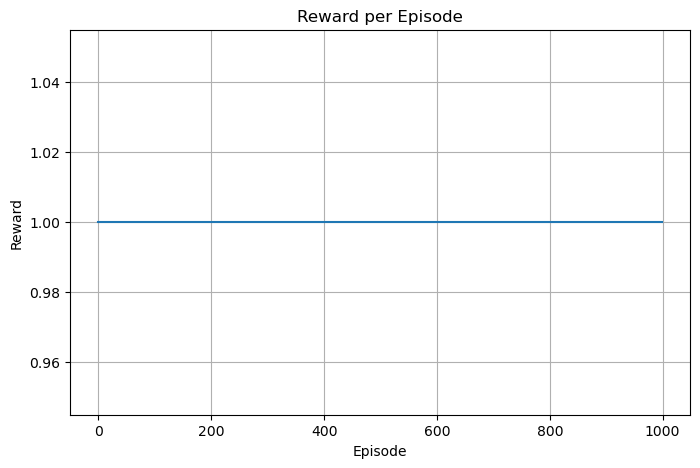

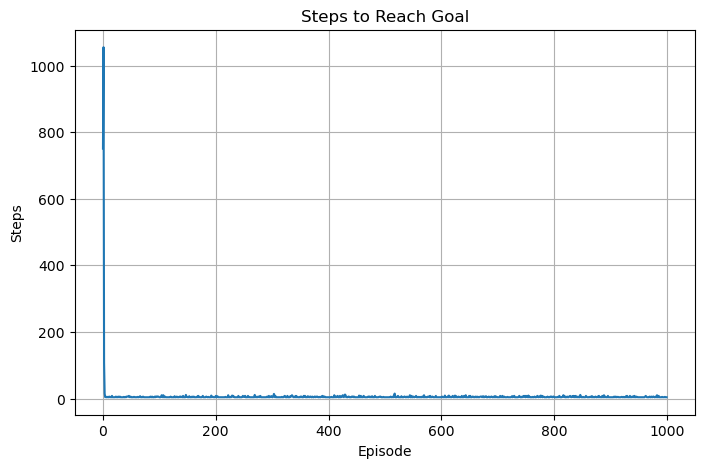

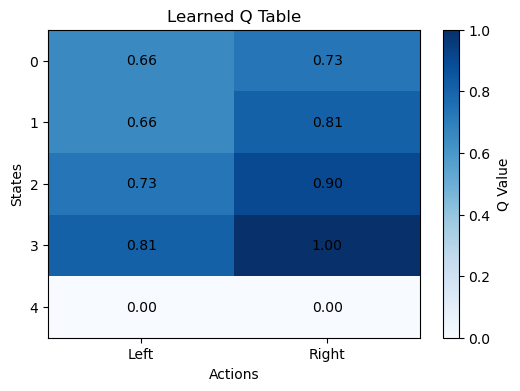

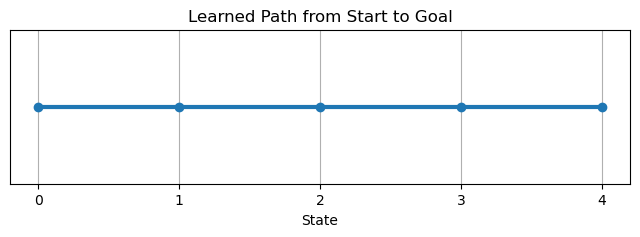

In [16]:
# ------------------------------------
# Reinforcement Learning - Q Learning
# ------------------------------------

import numpy as np
import random
import matplotlib.pyplot as plt

# ------------------------------------
# Environment
# ------------------------------------

n_states = 5
n_actions = 2      # 0 = Left, 1 = Right

Q = np.zeros((n_states, n_actions))

learning_rate = 0.1
discount = 0.9
epsilon = 0.2

episodes = 1000

# ------------------------------------
# Environment Function
# ------------------------------------

def step(state, action):

    if action == 1:
        next_state = min(state + 1, n_states - 1)
    else:
        next_state = max(state - 1, 0)

    reward = 1 if next_state == n_states - 1 else 0
    done = next_state == n_states - 1

    return next_state, reward, done


# ------------------------------------
# Training
# ------------------------------------

episode_rewards = []
episode_steps = []

for episode in range(episodes):

    state = 0
    done = False

    total_reward = 0
    steps = 0

    while not done:

        # Epsilon-Greedy Policy
        if random.uniform(0,1) < epsilon:
            action = random.randint(0,1)
        else:
            action = np.argmax(Q[state])

        next_state, reward, done = step(state, action)

        # Q-learning Update
        Q[state, action] = Q[state, action] + learning_rate * (
            reward +
            discount * np.max(Q[next_state]) -
            Q[state, action]
        )

        state = next_state

        total_reward += reward
        steps += 1

    episode_rewards.append(total_reward)
    episode_steps.append(steps)

# ------------------------------------
# Print Q Table
# ------------------------------------

print("="*50)
print("TRAINED Q TABLE")
print("="*50)

print(Q)

# ------------------------------------
# Test Learned Policy
# ------------------------------------

state = 0
path = [state]

while state != n_states-1:

    action = np.argmax(Q[state])

    state, _, _ = step(state, action)

    path.append(state)

print("\nLearned Path")
print(path)

# ------------------------------------
# Evaluation
# ------------------------------------

test_episodes = 100

success = 0
total_rewards = 0
total_steps = 0

for _ in range(test_episodes):

    state = 0
    done = False
    steps = 0
    reward_sum = 0

    while not done and steps < 20:

        action = np.argmax(Q[state])

        state, reward, done = step(state, action)

        reward_sum += reward
        steps += 1

    if done:
        success += 1

    total_rewards += reward_sum
    total_steps += steps

accuracy = success / test_episodes * 100
average_reward = total_rewards / test_episodes
average_steps = total_steps / test_episodes

print("\nEvaluation")
print("-"*30)

print(f"Success Rate : {accuracy:.2f}%")
print(f"Average Reward : {average_reward:.2f}")
print(f"Average Steps : {average_steps:.2f}")

# ------------------------------------
# Plot 1 - Reward per Episode
# ------------------------------------

plt.figure(figsize=(8,5))

plt.plot(episode_rewards)

plt.title("Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")

plt.grid(True)

plt.show()

# ------------------------------------
# Plot 2 - Steps per Episode
# ------------------------------------

plt.figure(figsize=(8,5))

plt.plot(episode_steps)

plt.title("Steps to Reach Goal")
plt.xlabel("Episode")
plt.ylabel("Steps")

plt.grid(True)

plt.show()

# ------------------------------------
# Plot 3 - Q Table Heatmap
# ------------------------------------

plt.figure(figsize=(6,4))

plt.imshow(Q, cmap="Blues", aspect="auto")

plt.colorbar(label="Q Value")

plt.xticks([0,1],["Left","Right"])
plt.yticks(range(n_states))

plt.xlabel("Actions")
plt.ylabel("States")
plt.title("Learned Q Table")

for i in range(n_states):
    for j in range(n_actions):
        plt.text(
            j,
            i,
            f"{Q[i,j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.show()

# ------------------------------------
# Plot 4 - Learned Path
# ------------------------------------

plt.figure(figsize=(8,2))

plt.plot(path,
         [1]*len(path),
         marker='o',
         linewidth=3)

plt.yticks([])

plt.xticks(range(n_states))

plt.xlabel("State")
plt.title("Learned Path from Start to Goal")

plt.grid(True)

plt.show()

Sentiment Analysis Results

Accuracy : 90.56%

Classification Report

              precision    recall  f1-score   support

    Negative       0.91      0.90      0.90      5000
    Positive       0.90      0.92      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000


Custom Predictions

Review: This movie was absolutely amazing and full of emotion.
Prediction: Positive 😊

Review: Worst movie I have ever watched.
Prediction: Negative 😞


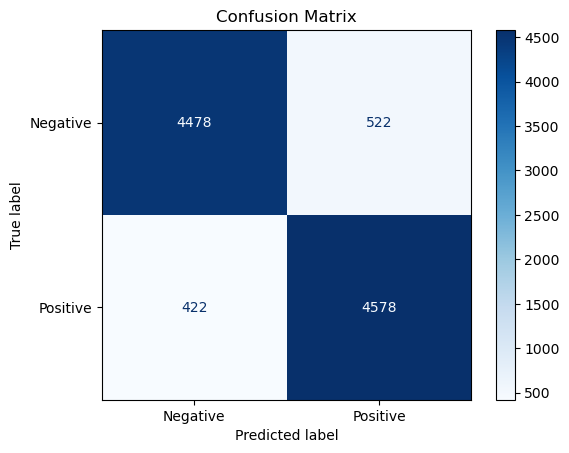

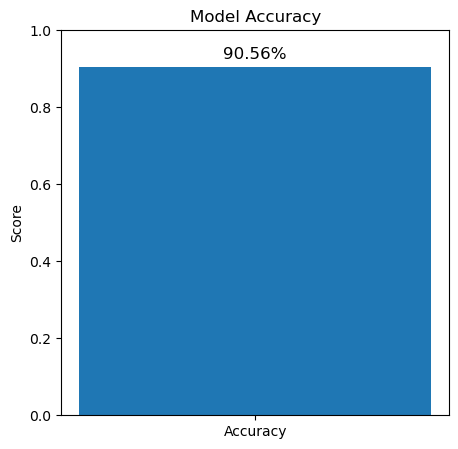

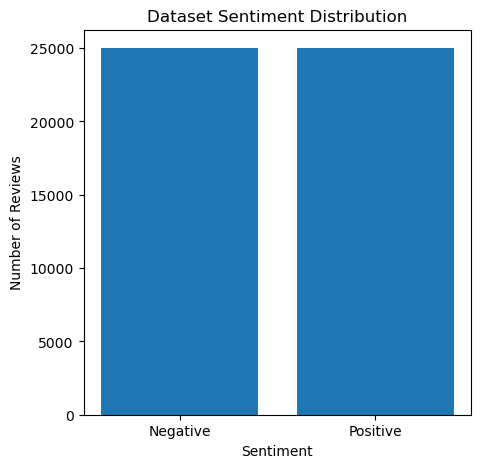

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ---------------------------------------
# Load Dataset
# ---------------------------------------

df = pd.read_csv("IMDB Dataset.csv")

# Convert labels to numeric
df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

X = df["review"]
y = df["sentiment"]

# ---------------------------------------
# Split Dataset
# ---------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ---------------------------------------
# Build Pipeline
# ---------------------------------------

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            max_features=20000,
            ngram_range=(1, 2),
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            C=2.0,
            random_state=42
        )
    )
])

# ---------------------------------------
# Train Model
# ---------------------------------------

model.fit(X_train, y_train)

# ---------------------------------------
# Predictions
# ---------------------------------------

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("=" * 50)
print("Sentiment Analysis Results")
print("=" * 50)

print(f"\nAccuracy : {accuracy*100:.2f}%")

print("\nClassification Report\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]
))

# ---------------------------------------
# Test Custom Review
# ---------------------------------------

sample_reviews = [
    "This movie was absolutely amazing and full of emotion.",
    "Worst movie I have ever watched."
]

predictions = model.predict(sample_reviews)

print("\nCustom Predictions")

for review, pred in zip(sample_reviews, predictions):
    sentiment = "Positive 😊" if pred == 1 else "Negative 😞"
    print(f"\nReview: {review}")
    print("Prediction:", sentiment)

# ---------------------------------------
# Confusion Matrix
# ---------------------------------------

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# ---------------------------------------
# Accuracy Bar Chart
# ---------------------------------------

plt.figure(figsize=(5,5))

plt.bar(["Accuracy"], [accuracy])

plt.ylim(0, 1)

plt.ylabel("Score")
plt.title("Model Accuracy")

plt.text(
    0,
    accuracy + 0.02,
    f"{accuracy*100:.2f}%",
    ha="center",
    fontsize=12
)

plt.show()

# ---------------------------------------
# Dataset Distribution
# ---------------------------------------

counts = df["sentiment"].value_counts().sort_index()

plt.figure(figsize=(5,5))

plt.bar(
    ["Negative", "Positive"],
    [counts[0], counts[1]]
)

plt.title("Dataset Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()